# My first exercise

## Question 1

How does age structure differ by China's four major regions?

### Hypothesis and arguments

Hpothesis: In NE China there is higher age on average...

### Operationalization

Age ist measured by Dependency Ratio of the Elederly Population


In [3]:
# Visualization reqires a special library. It may take a minute to load, so be patient.
library(ggplot2) 
# load data 
df = read.csv("ChinaRegionalData2024Mini.isle.csv", header = TRUE, stringsAsFactors = FALSE, fileEncoding = "UTF-8-BOM")
# Make variabl names accessible 
attach(df)
# Show names of all variables in the data set:
names(df)

 [1] "province_code"    "province"         "province_chinese" "region4"         
 [5] "regionmrs"        "regioneconomy"    "E02_05_c10"       "E02_07_c01"      
 [9] "E02_07_c02"       "E02_07_c04"       "E02_11_c02"       "E02_11_c03"      
[13] "E02_11_c04"       "E03_09_c01"       "E03_09_c02"       "E03_09_c03"      
[17] "E03_09_c04"       "E06_18_c07"       "E06_24_c07"       "E06_30_c07"      
[21] "hdi"              "lifeindex"        "eduindex"         "incomeindex"     
[25] "lexp"             "mys25"            "eys"              "gnipc"           
[29] "random"          

In [4]:
DPRE = E02_11_c04 / E02_11_c03
summary(DPRE)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.09002 0.19169 0.22920 0.22114 0.26836 0.32091 

### Data Analysis

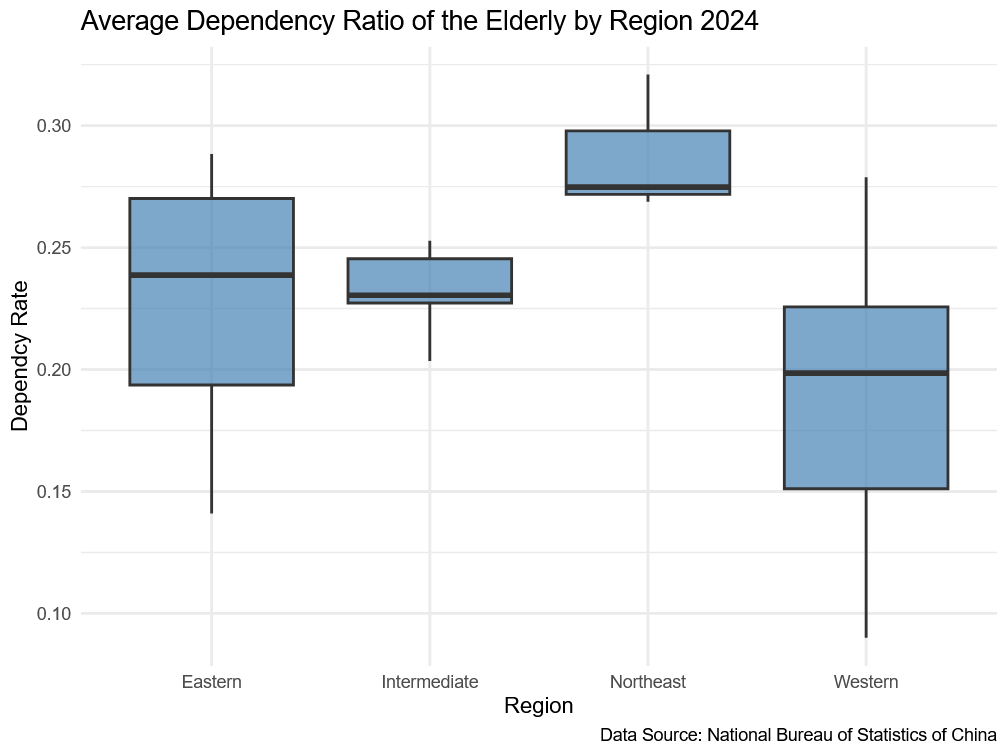

In [5]:
ggplot(df, aes(x = region4, y = DPRE)) +
  geom_boxplot(alpha = 0.7,                    # Transparency 
               fill = "steelblue") +           # Fill color
  labs(title = "Average Dependency Ratio of the Elderly by Region 2024",
       x = "Region",
       y = "Dependcy Rate",
       caption = "Data Source: National Bureau of Statistics of China") +
  theme_minimal() +
  theme(legend.position = "none")              # Remove legend (redundant here)

In [7]:
by(DPRE, region4, summary) # Summary, no standard deviation

region4: Eastern
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.1409  0.1937  0.2387  0.2293  0.2701  0.2884 
------------------------------------------------------------ 
region4: Intermediate
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.2035  0.2273  0.2305  0.2323  0.2454  0.2528 
------------------------------------------------------------ 
region4: Northeast
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.2688  0.2718  0.2748  0.2882  0.2978  0.3209 
------------------------------------------------------------ 
region4: Western
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.09002 0.15114 0.19856 0.19201 0.22570 0.27883 

### Description & Interpretation

As hypothesized, we observe high overall age and low variation in the north-eastern regions and lower age on average with high variation in the eastern coastal provinces . This is why ...

## Question 2

How is regional age structure associated with urbanization in China?

### Hypothesis and arguments

There is a negative association between average age and degree of urbanization, because ...

### Operationalization

Age structure is measured by the dependency rate of the ederly (see above). 
Urbanization is measured as ratio of urban population divided by total population

In [10]:
URBAN = E02_07_c02/E02_07_c01
summary(URBAN)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.3973  0.6121  0.6615  0.6678  0.7197  0.8984 

### Data Analysis

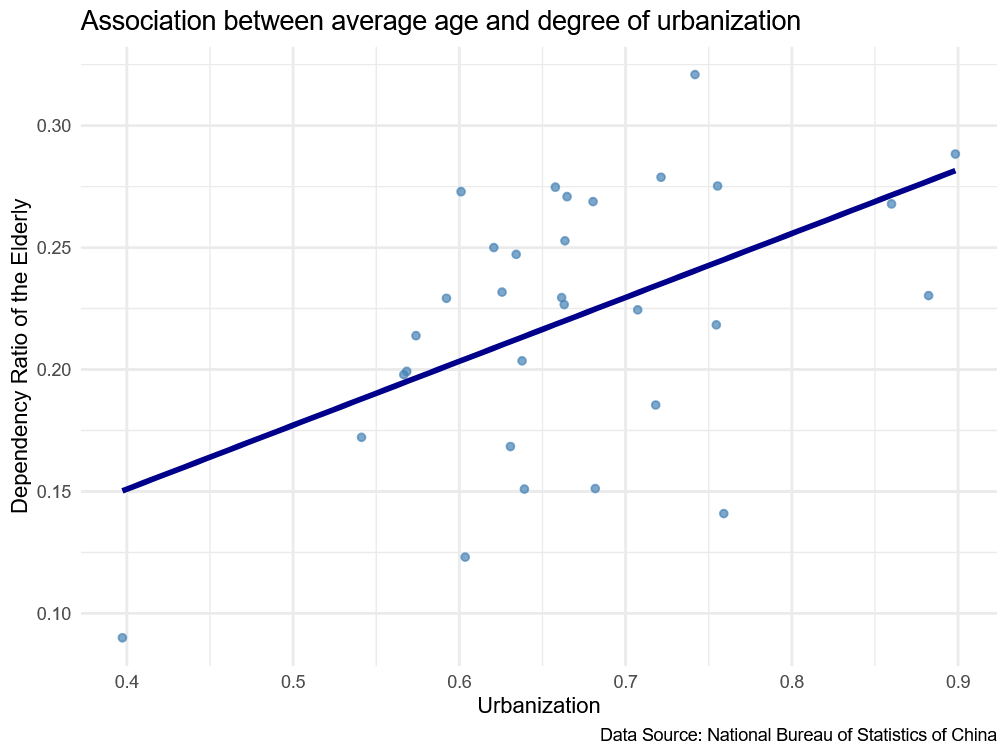

In [13]:
ggplot(df, aes(x = URBAN, y = DPRE)) +        # Define axes
  geom_point(alpha = 0.7,                    # Transparency of points
             color = "steelblue") +          # Color of points
  geom_smooth(method = "lm", formula = y ~ x, se = F, color = "darkblue") +  # regression line added
  labs(title = "Association between average age and degree of urbanization",
       x = "Urbanization",
       y = "Dependency Ratio of the Elderly",
       caption = "Data Source: National Bureau of Statistics of China") +
  theme_minimal() +
  theme(legend.position = "none")           # Remove legend

In [14]:
lm(DPRE ~ URBAN) # Regression Equation


Call:
lm(formula = DPRE ~ URBAN)

Coefficients:
(Intercept)        URBAN  
    0.04617      0.26199  


### Description & Interpretation

We observe a positive association that contradicts our hypothesis. For each increase of urbanization by 1 percentage point, the dependency rate of the elderly increases by 0.26 percentage points on average. In other words: Urbanization goes hand in hand with ageing population. The reason for this reslt lies in high birth reates 